In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import scienceplots
from scipy.special import factorial, hermite
plt.style.use('science')
plt.rcParams.update({'font.size': 14})

# Quantum Harmonic Oszillator

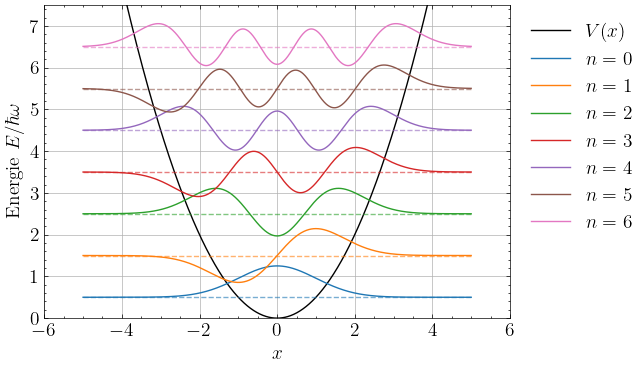

In [ ]:
m = 1.0
hbar = 1.0
omega = 1.0

alpha = np.sqrt(m*omega / hbar)

color_theme = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

def phi_n(n: int, x: np.ndarray) -> np.ndarray:
    N = np.sqrt(alpha / (np.sqrt(np.pi) * 2**n * factorial(n)))
    return N * np.exp(-alpha**2 * x**2 / 2) * hermite(n)(alpha * x)

def E_n(n: int) -> float:
    return hbar * omega * (n + 0.5)

def V(x):
    return 0.5 * m * omega**2 * x**2

def plot_phi_n(ax, n, x, color):
    ax.plot(x, np.ones_like(x) * E_n(n), color=color, linestyle='--', alpha=0.6)
    ax.plot(x, E_n(n) + phi_n(n, x), color=color, alpha=1, label=f'$n={n}$')

x = np.linspace(-5, 5, 1000)

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(x, V(x), color='black', linewidth=1, label='$V(x)$')

for n in range(7):
    current_color = color_theme[n % len(color_theme)]
    plot_phi_n(ax, n, x, current_color)

ax.set_ylim(0, E_n(7))
ax.set_xlim(-6, 6)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'Energie $E/\hbar \omega$')
ax.set_title('Quantum Harmonic Oszillator')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
ax.grid(True)

plt.tight_layout()
plt.show()


# Half Harmonic Oszillator

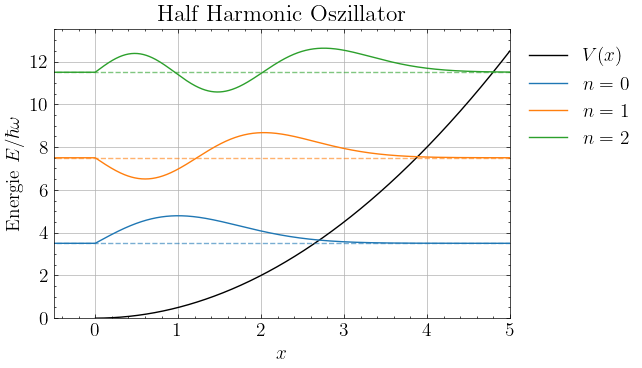

In [ ]:
m = 1.0
hbar = 1.0
omega = 1.0

alpha = np.sqrt(m*omega / hbar)

color_theme = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

def phi_n(n: int, x: np.ndarray) -> np.ndarray:
    N = np.sqrt(alpha / (np.sqrt(np.pi) * 2**n * factorial(n)))
    return np.where(x > 0, N * np.exp(-alpha**2 * x**2 / 2) * hermite(n)(alpha * x), 0)

def E_n(n: int) -> float:
    return hbar * omega * (2*n + 1.5)

def V(x):
    return np.where(x < 0, np.nan, 0.5 * m * omega**2 * x**2)

def plot_phi_n(ax, n, x, color):
    ax.plot(x, np.ones_like(x) * E_n(n), color=color, linestyle='--', alpha=0.6)

    # 2*phi_n nur für schöneren plot!
    ax.plot(x, E_n(n) + 2 * phi_n(n, x), color=color, alpha=1, label=f'$n={int((n - 1)/2)}$')

x = np.linspace(-1, 5, 1000)

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(x, V(x), color='black', linewidth=1, label='$V(x)$')

for n in range(3):

    c = color_theme[n % len(color_theme)]
    plot_phi_n(ax, 2*n + 1, x, c)

ax.set_ylim(0, E_n(6))
ax.set_xlim(-0.5, 5)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'Energie $E/\hbar \omega$')
ax.set_title('Half Harmonic Oszillator')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
ax.grid(True)

plt.tight_layout()
plt.show()

# Verschobener Oszillator

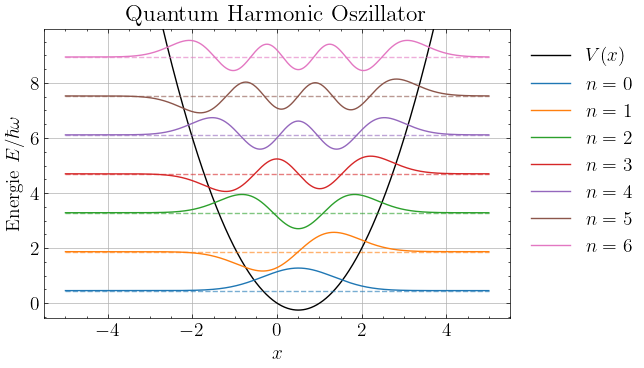

In [58]:
n_lim_plot = 6
x_lim = 5

m = 1.0
hbar = 1.0

a = 1
b = -1
omega = np.sqrt(2 * a / m)
alpha = np.sqrt(m*omega / hbar)

color_theme = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

def phi_n_0(n: int, x: np.ndarray) -> np.ndarray:
    N = np.sqrt(alpha / (np.sqrt(np.pi) * 2**n * factorial(n)))
    return N * np.exp(-alpha**2 * x**2 / 2) * hermite(n)(alpha * x)

def E_n(n: int) -> float:
    return hbar * omega * (n + 0.5) - b**2 / (4 * a)

def V(x):
    return a* x**2 + b * x

def plot_phi_n(ax, n, x, color):
    ax.plot(x, np.ones_like(x) * E_n(n), color=color, linestyle='--', alpha=0.6)
    ax.plot(x, E_n(n) + phi_n_0(n, x + b / (2 * a)), color=color, alpha=1, label=f'$n={n}$')

x = np.linspace(-x_lim, x_lim, 1000)

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(x, V(x), color='black', linewidth=1, label='$V(x)$')

for n in range(n_lim_plot + 1):
    current_color = color_theme[n % len(color_theme)]
    plot_phi_n(ax, n, x, current_color)

ax.set_ylim(E_n(0) - 1, E_n(n_lim_plot) + 1)
ax.set_xlim(-x_lim - 0.5, x_lim + 0.5)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'Energie $E/\hbar \omega$')
ax.set_title('Quantum Harmonic Oszillator')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
ax.grid(True)

plt.tight_layout()
plt.show()
